In [248]:
#import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [249]:
df = pd.read_csv("phishing_dataset (1).csv")

In [250]:
df.head()

,id,subject,sender,email_text,has_link,has_attachment,urgency_flag,label
0,1,Monthly Report,admin@company.com,Please find attached the monthly report.,1,0,0,legitimate
1,2,Salary Payment Notification,hr@company.com,Your salary has been credited successfully.,1,1,0,legitimate
2,3,Order Delivered,sales@shop.com,Your order has been delivered. Thank you for s...,0,1,0,legitimate
3,4,Salary Payment Notification,hr@company.com,Your salary has been credited successfully.,0,1,0,legitimate
4,5,Team Meeting Reminder,manager@company.com,Meeting scheduled for tomorrow at 10am.,0,0,0,legitimate


In [251]:
df.tail()

,id,subject,sender,email_text,has_link,has_attachment,urgency_flag,label
795,796,Congratulations Winner!,promo@lottery-ng.com,"You have won ??500,000. Click here to claim.",1,1,1,phishing
796,797,BVN Update Required,noreply@fakebank.com,Urgent: Update your BVN immediately to avoid r...,1,1,1,phishing
797,798,BVN Update Required,noreply@fakebank.com,Urgent: Update your BVN immediately to avoid r...,1,1,1,phishing
798,799,Order Delivered,sales@shop.com,Your order has been delivered. Thank you for s...,1,1,0,legitimate
799,800,Monthly Report,admin@company.com,Please find attached the monthly report.,1,1,0,legitimate


In [252]:
df.shape

(800, 8)

In [253]:
df.columns

Index(['id', 'subject', 'sender', 'email_text', 'has_link', 'has_attachment',
       'urgency_flag', 'label'],
      dtype='object')

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              800 non-null    int64 
 1   subject         800 non-null    object
 2   sender          800 non-null    object
 3   email_text      800 non-null    object
 4   has_link        800 non-null    int64 
 5   has_attachment  800 non-null    int64 
 6   urgency_flag    800 non-null    int64 
 7   label           800 non-null    object
dtypes: int64(4), object(4)
memory usage: 50.1+ KB


In [255]:
#Statistical summary
df.describe()

,id,has_link,has_attachment,urgency_flag
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,0.755000,0.520000,0.517500
std,231.0844,0.430356,0.499912,0.500006
min,1.0000,0.000000,0.000000,0.000000
25%,200.7500,1.000000,0.000000,0.000000
50%,400.5000,1.000000,1.000000,1.000000
75%,600.2500,1.000000,1.000000,1.000000
max,800.0000,1.000000,1.000000,1.000000


In [256]:
df.isnull().sum()

id                0
subject           0
sender            0
email_text        0
has_link          0
has_attachment    0
urgency_flag      0
label             0
dtype: int64

In [257]:
df.duplicated().sum()

np.int64(0)

In [258]:
df = df.drop_duplicates()

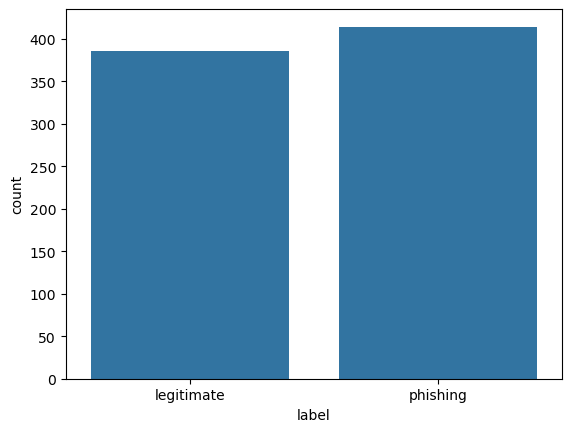

In [259]:
sns.countplot(x="label", data=df)
plt.show()

In [260]:
df["Word_Count"] = df["email_text"].apply(lambda x: len(str(x).split()))

In [261]:
import pandas as pd 
import numpy as np 
import re
import string 
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [262]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [263]:
#Convert to lowercase
df["email_text"] = df["email_text"].str.lower()

In [264]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df["email_text"] = df["email_text"].apply(remove_punctuation)

In [265]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

df["email_text"] = df["email_text"].apply(remove_urls)

In [266]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df["email_text"] = df["email_text"].apply(remove_numbers)

In [267]:
df["tokens"] = df["email_text"].apply(word_tokenize)

In [268]:
stop_words = set(stopwords.words("english"))
df["tokens"] = df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])

In [269]:
lemmatizer = WordNetLemmatizer()
df["tokens"] = df["tokens"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

In [270]:
df["clean_text"] = df["tokens"].apply(lambda words: " ".join(words))

In [271]:
print(df[["email_text", "clean_text"]].head())

                                          email_text  \
0            please find attached the monthly report   
1         your salary has been credited successfully   
2  your order has been delivered thank you for sh...   
3         your salary has been credited successfully   
4               meeting scheduled for tomorrow at am   

                            clean_text  
0  please find attached monthly report  
1         salary credited successfully  
2       order delivered thank shopping  
3         salary credited successfully  
4           meeting scheduled tomorrow  


In [272]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [273]:
x = df["clean_text"]
y = df["label"]
print(x.head())
print(y.head())

0    please find attached monthly report
1           salary credited successfully
2         order delivered thank shopping
3           salary credited successfully
4             meeting scheduled tomorrow
Name: clean_text, dtype: object
0    legitimate
1    legitimate
2    legitimate
3    legitimate
4    legitimate
Name: label, dtype: object


In [274]:
#Convert text into numbers
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(x)
print(x.shape)

(800, 34)


In [275]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print(x_train.shape)
print(x_test.shape)

(640, 34)
(160, 34)


In [276]:
#Train naive bayes
nb = MultinomialNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)

In [277]:
accuracy = accuracy_score(y_test, y_pred)
print("accuracy: ", accuracy)

accuracy:  1.0


In [278]:
#Train logistic Regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
prediction = lr.predict(x_test)

In [279]:
accuracy = accuracy_score(y_test, prediction)
print("accuracy: ", accuracy)

accuracy:  1.0


In [280]:
sample = ["Congratulations! Your application has recieved"]
sample = vectorizer.transform(sample)
prediction1 = lr.predict(sample)
print(prediction1)

['legitimate']


In [281]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [282]:
#Classification Report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00        72
    phishing       1.00      1.00      1.00        88

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [283]:
#Confusion Matrix
cm = confusion_matrix(y_test, prediction)
print(cm)

[[72  0]
 [ 0 88]]


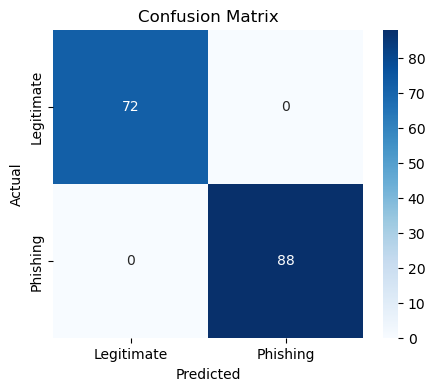

In [284]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["Legitimate", "Phishing"],
    yticklabels = ["Legitimate", "Phishing"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [285]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-xA-Z\s]', '', text)
    text = text.strip()
    return text

In [286]:
#Create a prediction function
def predict_email(email):
    cleaned = clean_text(email)
    vector = vectorizer.transform([cleaned])
    result = lr.predict(vector)

    if result[0] == 1:
        return "phishing email"
    else:
        return "legimitate email"

In [287]:
email1 = "Your application for scholarship has been submitted."
print(predict_email(email1))

legimitate email


In [288]:
import joblib

In [289]:
joblib.dump(lr, "phishing_dataset.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [290]:
import os
print(os.listdir())

['.git', 'notebook.ipynb', 'phishing_dataset (1).csv', 'phishing_dataset.pkl', 'README.md', 'tfidf_vectorizer.pkl']


In [291]:
print("Logistic Regression: ", accuracy_score(y_test, prediction))
print("Naive Bayes: ", accuracy_score(y_test, y_pred))

Logistic Regression:  1.0
Naive Bayes:  1.0


In [292]:
sample1 = "Your account has been temporarily locked due to unauthorized login attempts."
sample1 = clean_text(sample1)
sample1 = vectorizer.transform([sample1])
print(lr.predict(sample1))

['phishing']


In [293]:
sample2 = "Thank you for contacting customer support. Your enquiry has been recieved."
sample2 = clean_text(sample2)
sample2 = vectorizer.transform([sample2])
print(lr.predict(sample2))

['legitimate']


In [294]:
test_email = [
    "Could you please send over the latest draft of marketing proposal whenever you have a moment.",
    "We detected a password change request from your account from an unknown device.",
    "Congratulations! Your application has been selected to recieve a free $500 gift card.",
]
for email in test_email:
    prediction_of_email = predict_email(email)
    print(f"\nEmail: {email}")
    print(f"Prediction: {prediction_of_email}")


Email: Could you please send over the latest draft of marketing proposal whenever you have a moment.
Prediction: legimitate email

Email: We detected a password change request from your account from an unknown device.
Prediction: legimitate email

Email: Congratulations! Your application has been selected to recieve a free $500 gift card.
Prediction: legimitate email


In [295]:
cleaned = clean_text(test_email[0])
vector = vectorizer.transform([cleaned])
probability = lr.predict_proba(vector)
print(probability)

[[0.8165596 0.1834404]]


In [296]:
print("legitimate email probability: ", probability[0][0])
print("Phishing email probability: ", probability[0][1])

legitimate email probability:  0.8165596033589502
Phishing email probability:  0.18344039664104989


In [297]:
def predict_email_with_confidence(email):

    cleaned = clean_text(email)
    vector = vectorizer.transform([cleaned])
    prediction = lr.predict(vector)[0]
    probability = lr.predict_proba(vector)
    confidence = max(probability[0]) * 100

    if prediction == 1:
        result = "Phishing email"
    else:
        result = "Legitimate email"

    return result, confidence

In [298]:
emails = "We detected a password change request from your account."

result, confidence = predict_email_with_confidence(emails)

print("Prediction2 :", result)
print("Confidence :", round(confidence,2),"%")

Prediction2 : Legitimate email
Confidence : 84.03 %


In [299]:
import time
start = time.time()
predict_email(email)
end = time.time()
print("Prediction Time: ", end-start, "seconds")

Prediction Time:  0.001622915267944336 seconds


In [300]:
print(type(prediction))
print(type(y_pred))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [301]:
logistic_accuracy = accuracy_score(y_test, prediction)
nb_accuracy = accuracy_score(y_test, y_pred)

In [302]:
models = {
    "Logistic Regression ": logistic_accuracy,
    "Naive Bayes ": nb_accuracy
}
for name, score in models.items():
    print(name, ":", round(score*100, 2), "%")

Logistic Regression  : 100.0 %
Naive Bayes  : 100.0 %


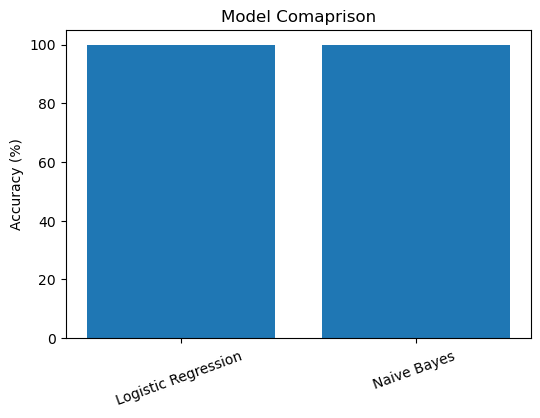

In [304]:
import matplotlib.pyplot as plt
names = list(models.keys())
scores = [score*100 for  score in models.values()]
plt.figure(figsize=(6, 4))
plt.bar(names, scores)
plt.ylabel("Accuracy (%)")
plt.title("Model Comaprison")
plt.xticks(rotation = 20)
plt.show()